In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
infile = xr.open_dataset('D:/data/ibtracs/IBTrACS.WP.v04r01.nc')
infile

<xarray.Dataset> Size: 1GB
Dimensions:           (storm: 4176, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 12MB ...
    lat               (storm, date_time) float32 6MB ...
    lon               (storm, date_time) float32 6MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/159)
    numobs            (storm) float32 17kB ...
    sid               (storm) |S13 54kB ...
    season            (storm) float32 17kB ...
    number            (storm) int16 8kB ...
    basin             (storm, date_time) |S2 3MB ...
    subbasin          (storm, date_time) |S2 3MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 6MB ...
    reunion_gust_per  (storm, date_time) float32 6MB ...
    usa_seahgt        (storm, date_time) float32 6MB ...
    usa_searad        (storm, date_time, quadrant) float32 24MB ...
    storm_speed       (storm, date_time) float32 6MB ...
    storm_dir         (storm, date_time) float32 6MB ...
Attributes: (12/49)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r01
    ...                         ...
    history:                    Tue Sep 24 05:54:34 2024: ncks --no_abc --cnk...
    license:                    These data may be redistributed and used with...
    featureType:                trajectory
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    NCO:                        netCDF Operators version 5.0.7 (Homepage = ht...

In [3]:
censea=infile['season']
tim=infile['time']
centim=tim.dt.month[:,0]
centyp=infile['track_type']
cenatu=infile['nature']
numnat= np.sum(np.isin(cenatu, [b'DS', b'ET']), axis=1)#有多少个DS,ET,要这俩=0的地方
cenlat=infile['usa_lat']
nummia=np.sum(np.isnan(cenlat), axis=1)
numnma=np.sum(~np.isnan(cenlat), axis=1)  
cenlon=infile['usa_lon']
nummio=np.sum(np.isnan(cenlon), axis=1) 
numnmo=np.sum(~np.isnan(cenlon), axis=1)  
cenwin=infile['usa_wind']
nummiw=np.sum(np.isnan(cenwin), axis=1)   #每行nan个数
numnmw=np.sum(~np.isnan(cenwin), axis=1)  
maxwin = np.amax(cenwin, axis=1) 
cenatu=infile['nature']
numnat= np.sum(np.isin(cenatu, [b'DS', b'ET']), axis=1)#有多少个DS,ET,要这俩=0的地方
numb=np.sum(cenatu != b'', axis=1)#非空值的个数，用于去除空值以及小于48小时的情况,numb>16,3h
indnat=np.where((numb!=numnat)&(numb>16))
lat = infile['usa_lat']

# 创建布尔掩码以筛选7、8、9月份的数据
mask = lat['time'].dt.month.isin([7, 8, 9])

# 保留掩码对应的数据并将其他数据设为NaN
lat2 = lat.where(mask, drop=True)

# 打印筛选后的数据以检查结果
# print(lat2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.title(title,loc='left',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)


    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
#     plt.text(1992, 1.05, f"Slope: {slope:.3f} ± {std_err:.3f}  per decade", fontsize=15, color='black')
    
    plt.show()
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, tomecur_totle, 'dist/km', 'Dist over Years', 17)


In [5]:
years = np.arange(1982, 2024)
split_index=17

## 所有的总强度

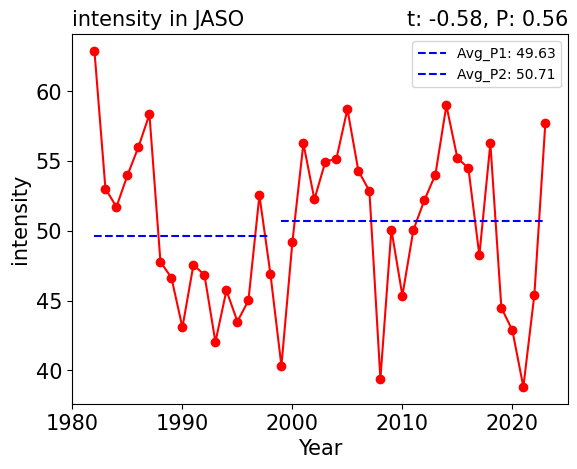

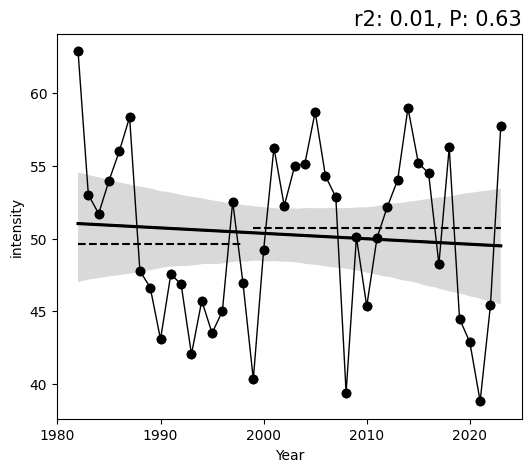

R: -0.07724052882667667
P: 0.6268277770445028
R2: 0.005966099293424671


In [6]:
tomecur=[]
tonccur=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16)))
    numatc=np.array(indall).shape[1]#台风个数tonccur

   
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])

        cur=np.mean(arrwin)
#             if cur<4.96:
#             print(cur)
        tocur.append(cur)
        mecur=np.mean(tocur)#平均曲率
    tomecur.append(mecur)#40yr平均曲率
tomecur_totle=tomecur


plot_change_data(years,tomecur_totle, 'intensity', 'intensity in JASO', 17)



#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('intensity')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

## C3全部

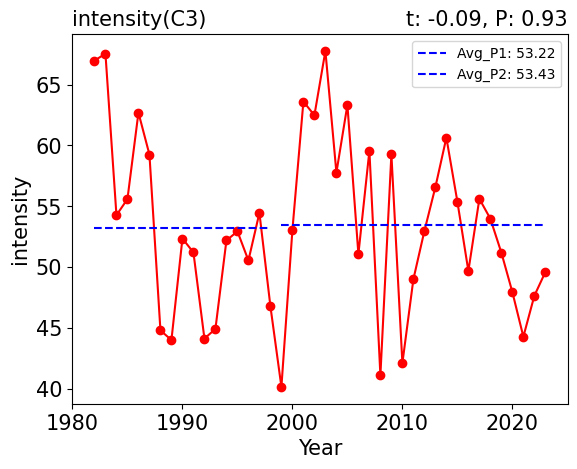

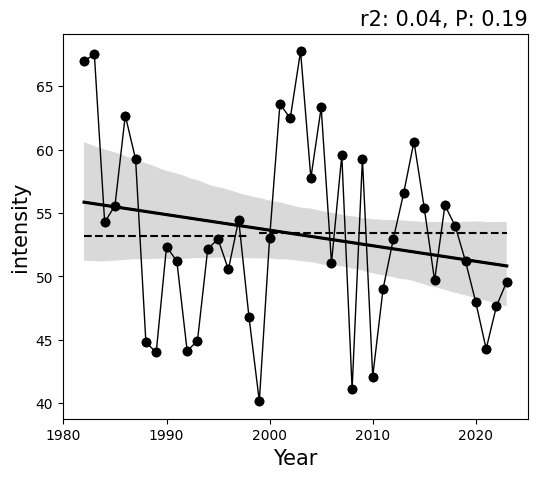

R: -0.20531147672937758
P: 0.1921101368512372
R2: 0.04215280247679775


In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')

# 要去掉的 Typhoon ID


tomecur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        cur=np.mean(arrwin)#一个TC          
        tocur.append(cur)#一年TC
   
        mecur=np.mean(tocur)
    tomecur.append(mecur)

        

y = tomecur


plot_change_data(years, y, 'intensity', 'intensity(C3)', 17)

ccc=y
#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year',fontsize=15)
plt.ylabel('intensity',fontsize=15)
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

## C3框内

[2792 2794 2797 2798 2800 2802 2805]
[2816 2818 2820 2823 2828 2831]
[2845 2851 2861 2863 2869]
[2887 2888 2890 2892 2894 2895 2902]
[2922 2925 2928 2929 2934 2935]
[2954 2962 2967 2971 2972]
[2985 2997 3005]
[3027 3039]
[3074 3076 3082 3083]
[3103 3111 3114 3115 3116 3119]
[3139 3151 3153 3155 3159]
[3176 3177 3178 3179 3186 3187]
[3216 3220 3235 3236 3238 3247]
[3254 3269]
[]
[3342 3344]
[3369 3378 3380]
[3406 3408 3420 3421 3422 3424]
[3437 3441 3442 3446 3451 3453 3456 3461]
[3475 3478 3481 3487 3492 3493]
[3511 3512 3516 3519 3522]
[3546 3553 3555 3558]
[3578 3580 3584 3588 3591 3592 3593]
[3611 3613 3618 3621]
[3635 3637 3638 3641 3646]
[3657 3658 3663 3665]
[3689 3694 3699 3702 3706]
[3720 3724 3728 3732 3734]
[3748 3751 3753 3754 3756 3760]
[3776 3780 3783]
[3800 3807 3808 3809 3810 3813 3814]
[3836 3838 3839 3842 3845 3846 3848 3849]
[3866 3870 3871 3873 3878 3879 3880]
[3894 3900 3903 3905 3908]
[3922 3923 3924 3927 3928 3930 3935 3937]
[3952 3954 3964 3967 3972 3974]
[3997 3

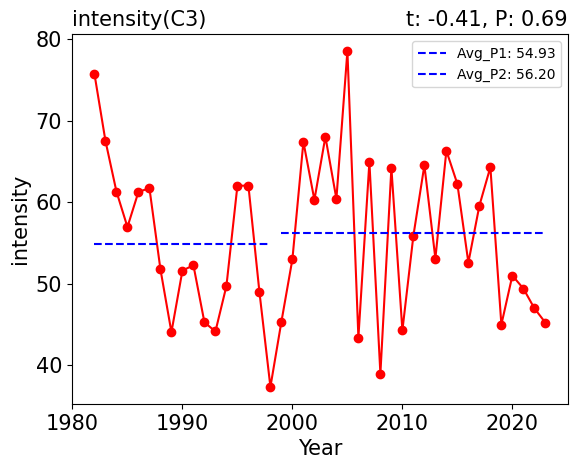

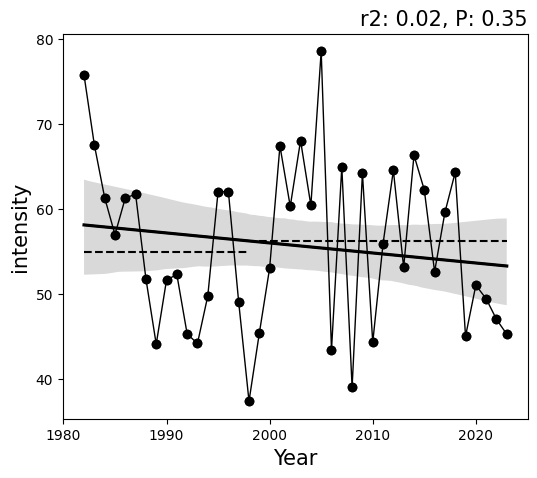

R: -0.14740099955202327
P: 0.3515737365752476
R2: 0.021727054668935562


In [8]:
#框内数量
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')

# 定义框的经纬度范围
lon_min, lon_max = 125, 155
lat_min, lat_max = 30, 45

# 1982-2023年所有数据
df_period = df[(df['year'] >= 1982) & (df['year'] <= 2023)]


df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                   (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)]

tomecur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df_inside_box[df_inside_box['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    print(indall)
    
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        cur=np.mean(arrwin)#一个TC          
        tocur.append(cur)#一年TC
   
        mecur=np.mean(tocur)
    tomecur.append(mecur)


y = tomecur


plot_change_data(years, y, 'intensity', 'intensity(C3)', 17)

ccc=y
#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year',fontsize=15)
plt.ylabel('intensity',fontsize=15)
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

## C3登陆

In [9]:
cendis=infile['dist2land']
nummid=np.sum(np.isnan(cendis), axis=1)   
numnmd=np.sum(~np.isnan(cendis), axis=1)  #非nan数
num0md=np.sum(cendis==0, axis=1) #每行几个0
inddis=np.where((numnmd>=16)&(num0md>0))  #0代表登陆，看有几个0
numdis=cendis[inddis]#登录的结果
landindall=[]
landindallin=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16))
                    &((numnmd>=16)&(num0md>0)))
    landindall.append(indall[0])
landindall_flat = np.concatenate(landindall).tolist()  # 将所有数组拼接并转换为列表

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data_3(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title,loc='left',fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

#     print(f"t-statistic: {t_stat}")
#     print(f"p-value: {p_value}")
    
    
    plt.title(f't:{t_stat:.2f},p:{p_value:.3f}',loc='right',fontsize=12)
    
    plt.show()


# years = np.arange(1982, 2024)
# data = np.random.rand(40) * 100  # 示例数据
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, data, 'dist/km', 'Dist over Years', split_index)


In [11]:
def count_typhoons_in_box(df, lon_min, lon_max, lat_min, lat_max):
    # 过滤框内的台风数据
    df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                       (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)]
    
    # 统计每年框内的台风数量
    typhoon_count_per_year = df_inside_box.groupby('year').size()
    
    return typhoon_count_per_year


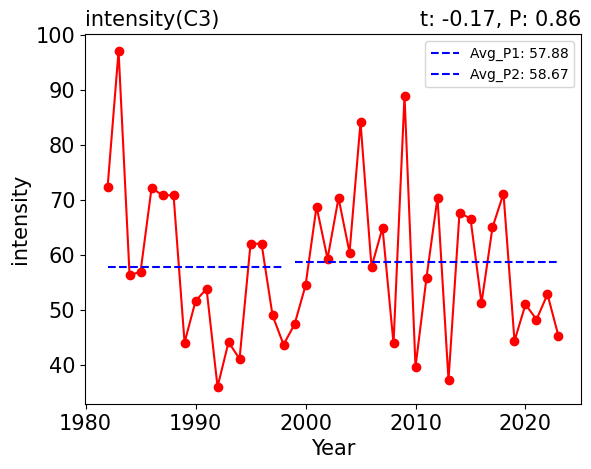

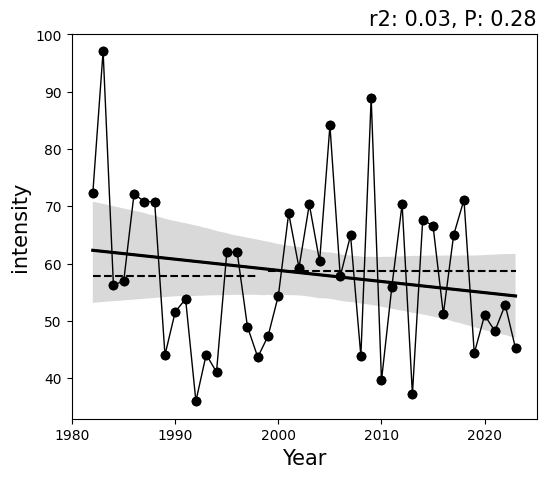

R: -0.17112168677616277
P: 0.27856697477776404
R2: 0.02928263168511916


In [12]:
#框内数量
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')

# 定义框的经纬度范围
lon_min, lon_max = 125, 155
lat_min, lat_max = 30,45

# 1982-2023年所有数据
df_period = df[(df['year'] >= 1982) & (df['year'] <= 2023)]

# 统计每年框内的台风数量


df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                   (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)&
                    (df['Typhoon ID'].isin(landindall_flat))
                  ]
    


# 获取每年框内的台风数量
typhoon_count = count_typhoons_in_box(df_period, lon_min, lon_max, lat_min, lat_max)

# 将没有台风数据的年份填充为0
years = list(range(1982, 2024))
typhoon_count = typhoon_count.reindex(years, fill_value=0)

tomecur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df_inside_box[df_inside_box['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
#     print(indall)
    
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        cur=np.mean(arrwin)#一个TC          
        tocur.append(cur)#一年TC
   
        mecur=np.mean(tocur)
    tomecur.append(mecur)


y = tomecur


plot_change_data(years, y, 'intensity', 'intensity(C3)', 17)

ccc=y
#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year',fontsize=15)
plt.ylabel('intensity',fontsize=15)
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

## 35-95 C3类数量

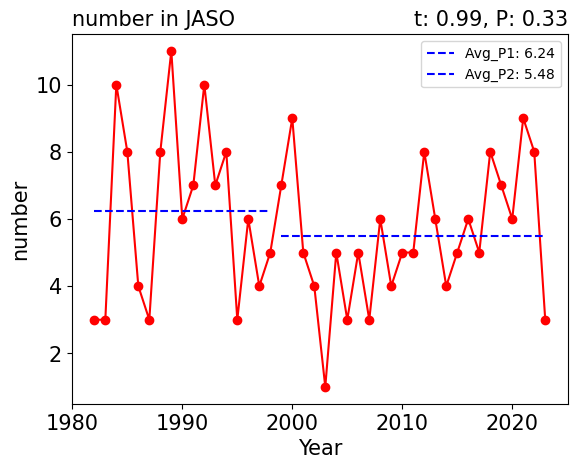

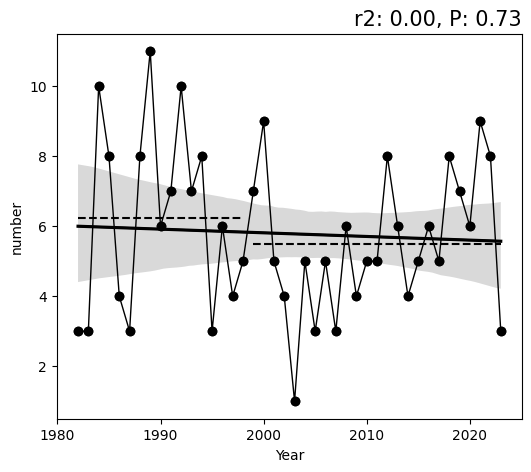

R: -0.05573117558687243
P: 0.7259244312533779
R2: 0.003105963932294806


In [13]:
tomecur=[]
tonccur=[]
for year in range(1982,2024):  
    indall1 = np.where((censea==year)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35)&(maxwin<=95))
                    &((numb!=numnat)&(numb>=16)))[0]
#     print(indall1)
    year_data = df[df['year'] == year]
    indall2 = year_data['Typhoon ID'].unique()
#     print(indall2)
    
    indall = np.intersect1d(indall1, indall2)
#     print(indall)
    numatc=np.array(indall).shape[0]#台风个数tonccur

    tomecur.append(numatc)#40yr平均曲率
tomecur_totle=tomecur

plot_change_data(years,tomecur_totle, 'number', 'number in JASO', 17)

y5=tomecur_totle

#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('number')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

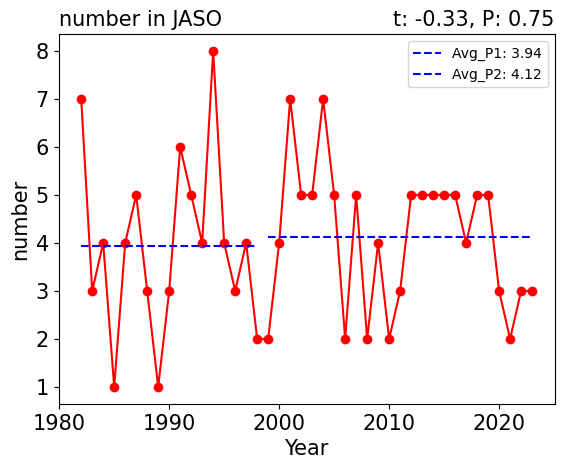

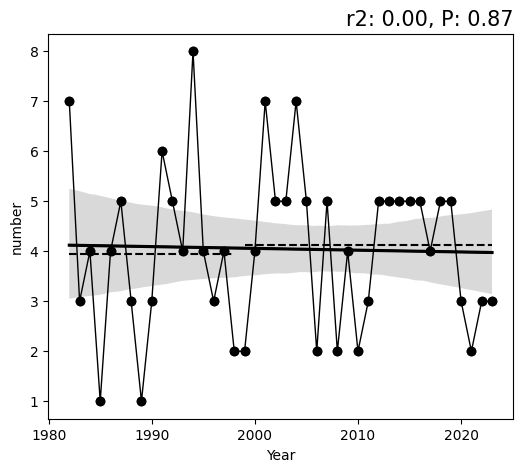

R: -0.026714942737308806
P: 0.8666323948597827
R2: 0.0007136881654576885


In [14]:
tomecur=[]
tonccur=[]
for year in range(1982,2024):  
    indall1 = np.where((censea==year)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=96))
                    &((numb!=numnat)&(numb>=16)))[0]
#     print(indall1)
    year_data = df[df['year'] == year]
    indall2 = year_data['Typhoon ID'].unique()
#     print(indall2)
    
    indall = np.intersect1d(indall1, indall2)
#     print(indall)
    numatc=np.array(indall).shape[0]#台风个数tonccur

    tomecur.append(numatc)#40yr平均曲率
tomecur_totle=tomecur
y6=tomecur_totle
plot_change_data(years,tomecur_totle, 'number', 'number in JASO', 17)



#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('number')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

## 35-95 C3类框内数量

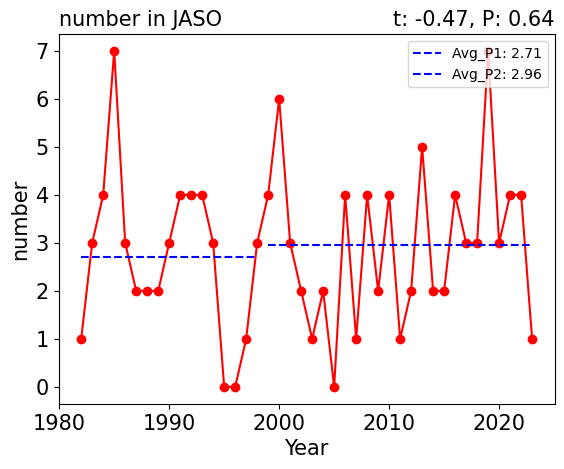

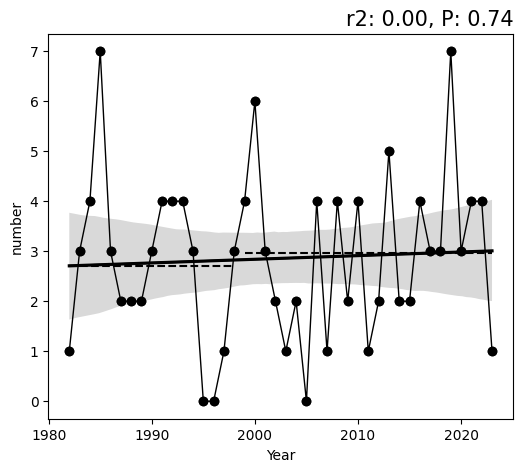

R: 0.053386793176206475
P: 0.7370336126753223
R2: 0.002850149685639046


In [15]:
tomecur=[]
tonccur=[]
df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                   (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)]
for year in range(1982,2024):  
    indall1 = np.where((censea==year)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35)&(maxwin<=95))
                    &((numb!=numnat)&(numb>=16)))[0]
#     print(indall1)
    year_data = df_inside_box[df_inside_box['year'] == year]
    indall2 = year_data['Typhoon ID'].unique()
#     print(indall2)
    
    indall = np.intersect1d(indall1, indall2)
#     print(indall)
    numatc=np.array(indall).shape[0]#台风个数tonccur

    tomecur.append(numatc)#40yr平均曲率
tomecur_totle=tomecur

plot_change_data(years,tomecur_totle, 'number', 'number in JASO', 17)

y1=tomecur_totle

#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur_totle
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('number')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

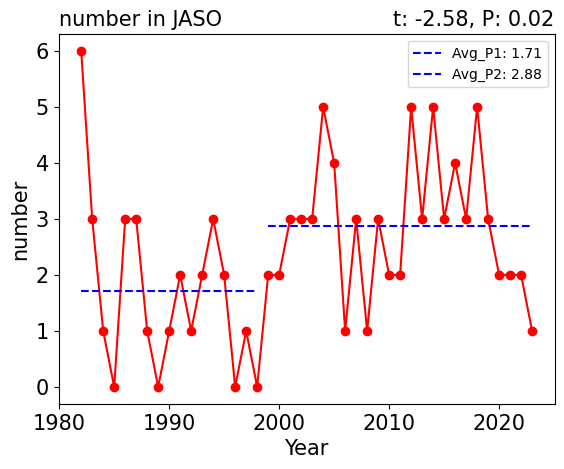

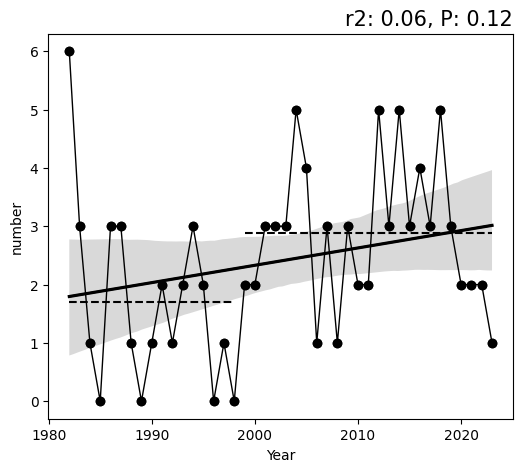

R: 0.24607505652854683
P: 0.11620931351827939
R2: 0.06055293344552752


In [16]:
tomecur=[]
tonccur=[]
df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                   (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)]
for year in range(1982,2024):  
    indall1 = np.where((censea==year)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=96))
                    &((numb!=numnat)&(numb>=16)))[0]
#     print(indall1)
    year_data = df_inside_box[df_inside_box['year'] == year]
    indall2 = year_data['Typhoon ID'].unique()
#     print(indall2)
    
    indall = np.intersect1d(indall1, indall2)
#     print(indall)
    numatc=np.array(indall).shape[0]#台风个数tonccur

    tomecur.append(numatc)#40yr平均曲率
tomecur_totle=tomecur

plot_change_data(years,tomecur_totle, 'number', 'number in JASO', 17)

y2=tomecur_totle

#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur_totle
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('number')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

## 35-95 C3类框内登陆数量

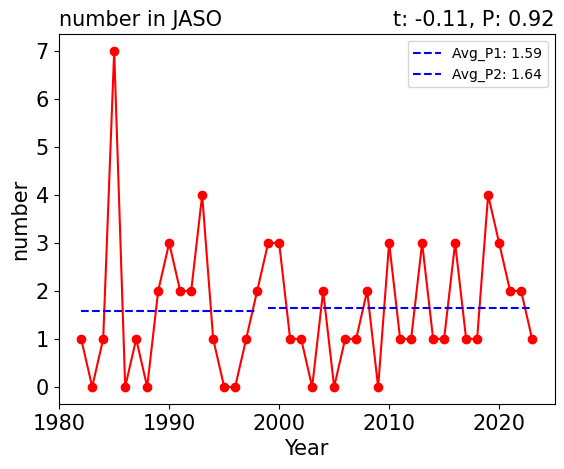

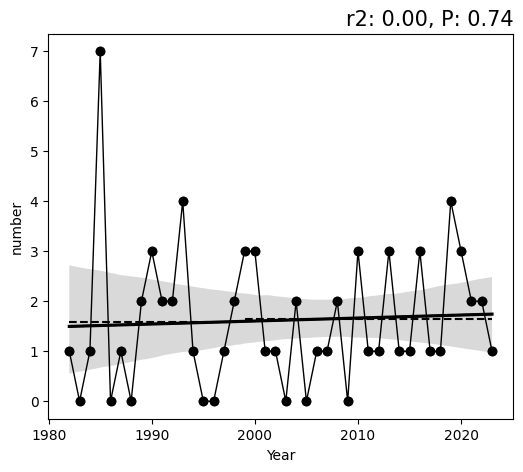

R: 0.052045953534041754
P: 0.7434113773070277
R2: 0.0027087812792676333


In [17]:
tomecur=[]
tonccur=[]
df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                   (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)&
                    (df['Typhoon ID'].isin(landindall_flat))
                  ]
for year in range(1982,2024):  
    indall1 = np.where((censea==year)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35)&(maxwin<=95))
                    &((numb!=numnat)&(numb>=16)))[0]
#     print(indall1)
    year_data = df_inside_box[df_inside_box['year'] == year]
    indall2 = year_data['Typhoon ID'].unique()
#     print(indall2)
    
    indall = np.intersect1d(indall1, indall2)
#     print(indall)
    numatc=np.array(indall).shape[0]#台风个数tonccur

    tomecur.append(numatc)#40yr平均曲率
tomecur_totle=tomecur

plot_change_data(years,tomecur_totle, 'number', 'number in JASO', 17)

y3=tomecur_totle

#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('number')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

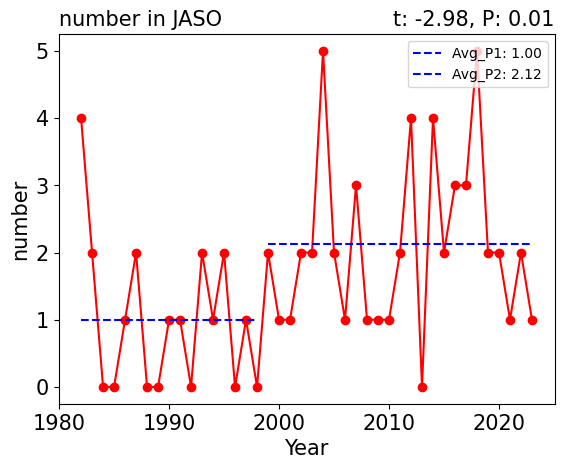

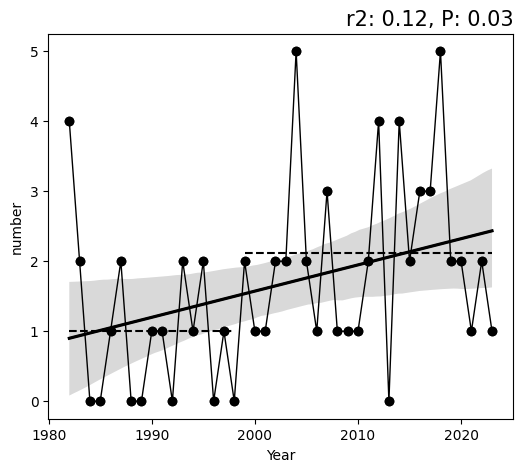

R: 0.343400630741151
P: 0.02597929909325525
R2: 0.11792399319342035


In [18]:
tomecur=[]
tonccur=[]
df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                   (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)&
                    (df['Typhoon ID'].isin(landindall_flat))
                  ]
for year in range(1982,2024):  
    indall1 = np.where((censea==year)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=96))
                    &((numb!=numnat)&(numb>=16)))[0]
#     print(indall1)
    year_data = df_inside_box[df_inside_box['year'] == year]
    indall2 = year_data['Typhoon ID'].unique()
#     print(indall2)
    
    indall = np.intersect1d(indall1, indall2)
#     print(indall)
    numatc=np.array(indall).shape[0]#台风个数tonccur

    tomecur.append(numatc)#40yr平均曲率
tomecur_totle=tomecur

plot_change_data(years,tomecur_totle, 'number', 'number in JASO', 17)
y4=tomecur_totle

#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur_totle
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('number')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

## 组图

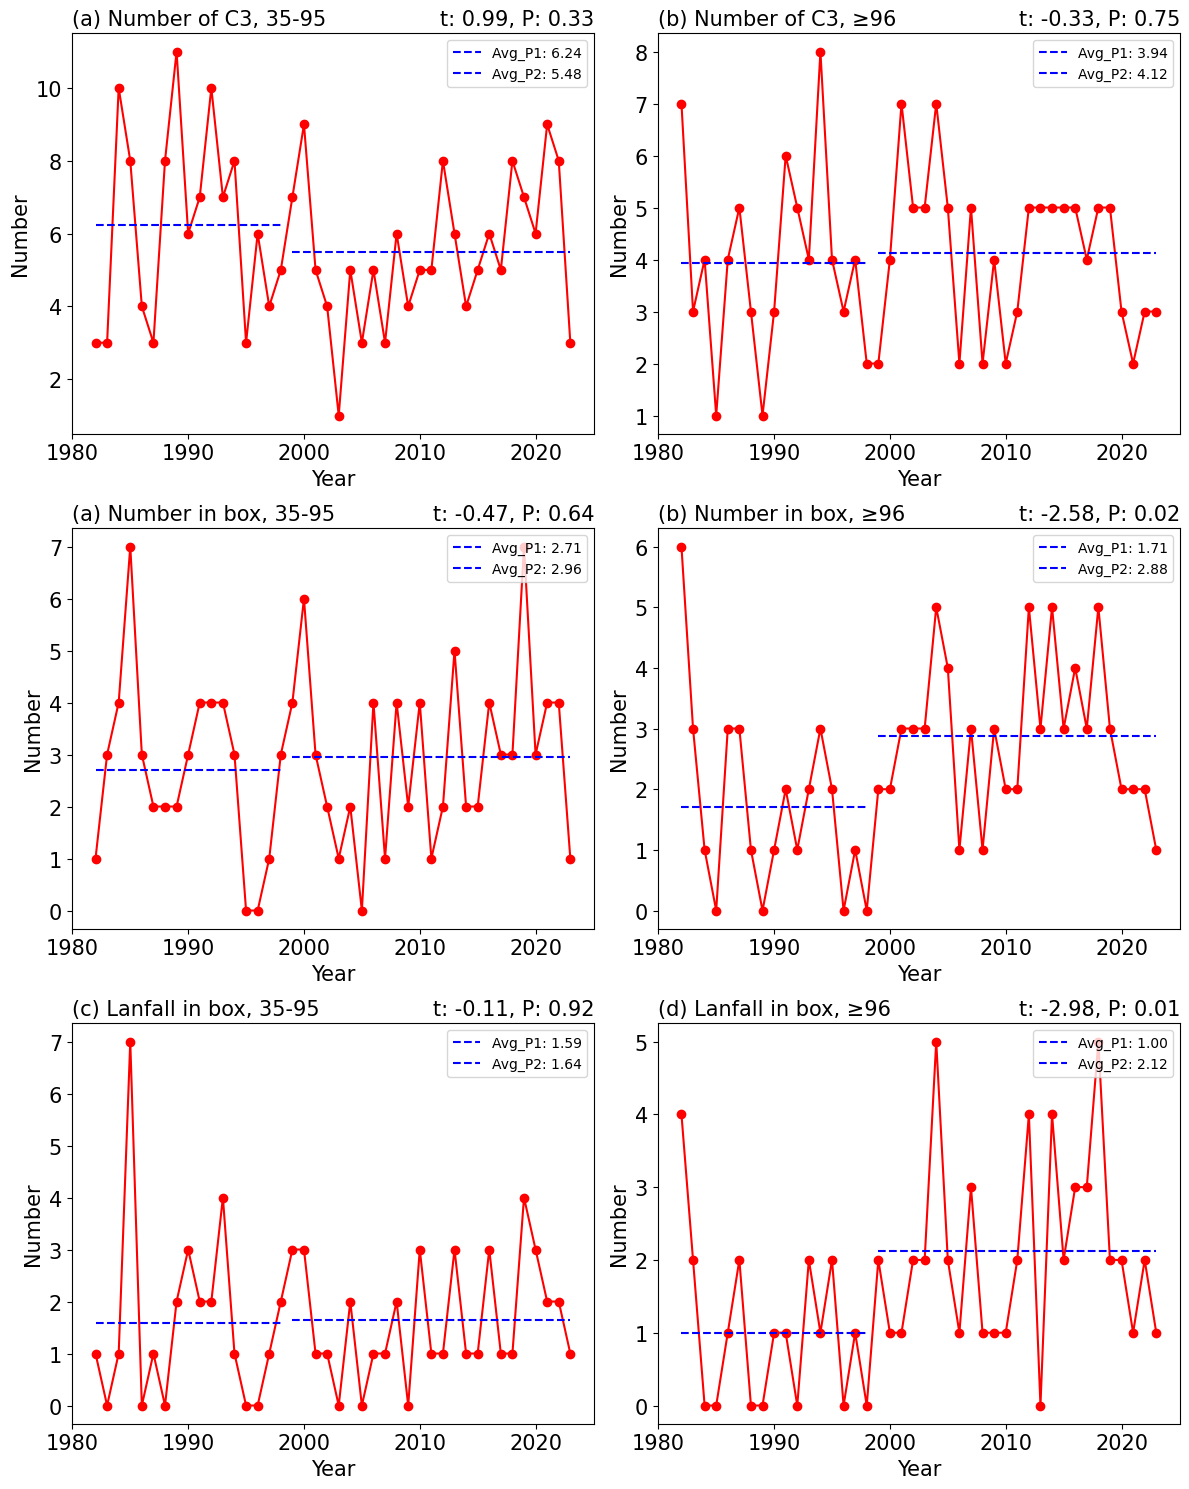

In [19]:
split_index=17
fig=plt.figure(figsize=(12,15))

ax5 = fig.add_subplot(3, 2, 1)
ax=ax5
data=np.array(y5)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(a) Number of C3, 35-95',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax6 = fig.add_subplot(3, 2, 2)
ax=ax6
data=np.array(y6)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(b) Number of C3, ≥96',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax1 = fig.add_subplot(3, 2, 3)
ax=ax1
data=np.array(y1)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(a) Number in box, 35-95',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax2 = fig.add_subplot(3, 2, 4)
ax=ax2
data=y2
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(b) Number in box, ≥96',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax3 = fig.add_subplot(3, 2, 5)
ax=ax3
data=y3
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(c) Lanfall in box, 35-95',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax4 = fig.add_subplot(3, 2, 6)
ax=ax4
data=y4
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(d) Lanfall in box, ≥96',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
plt.tight_layout()
plt.show()

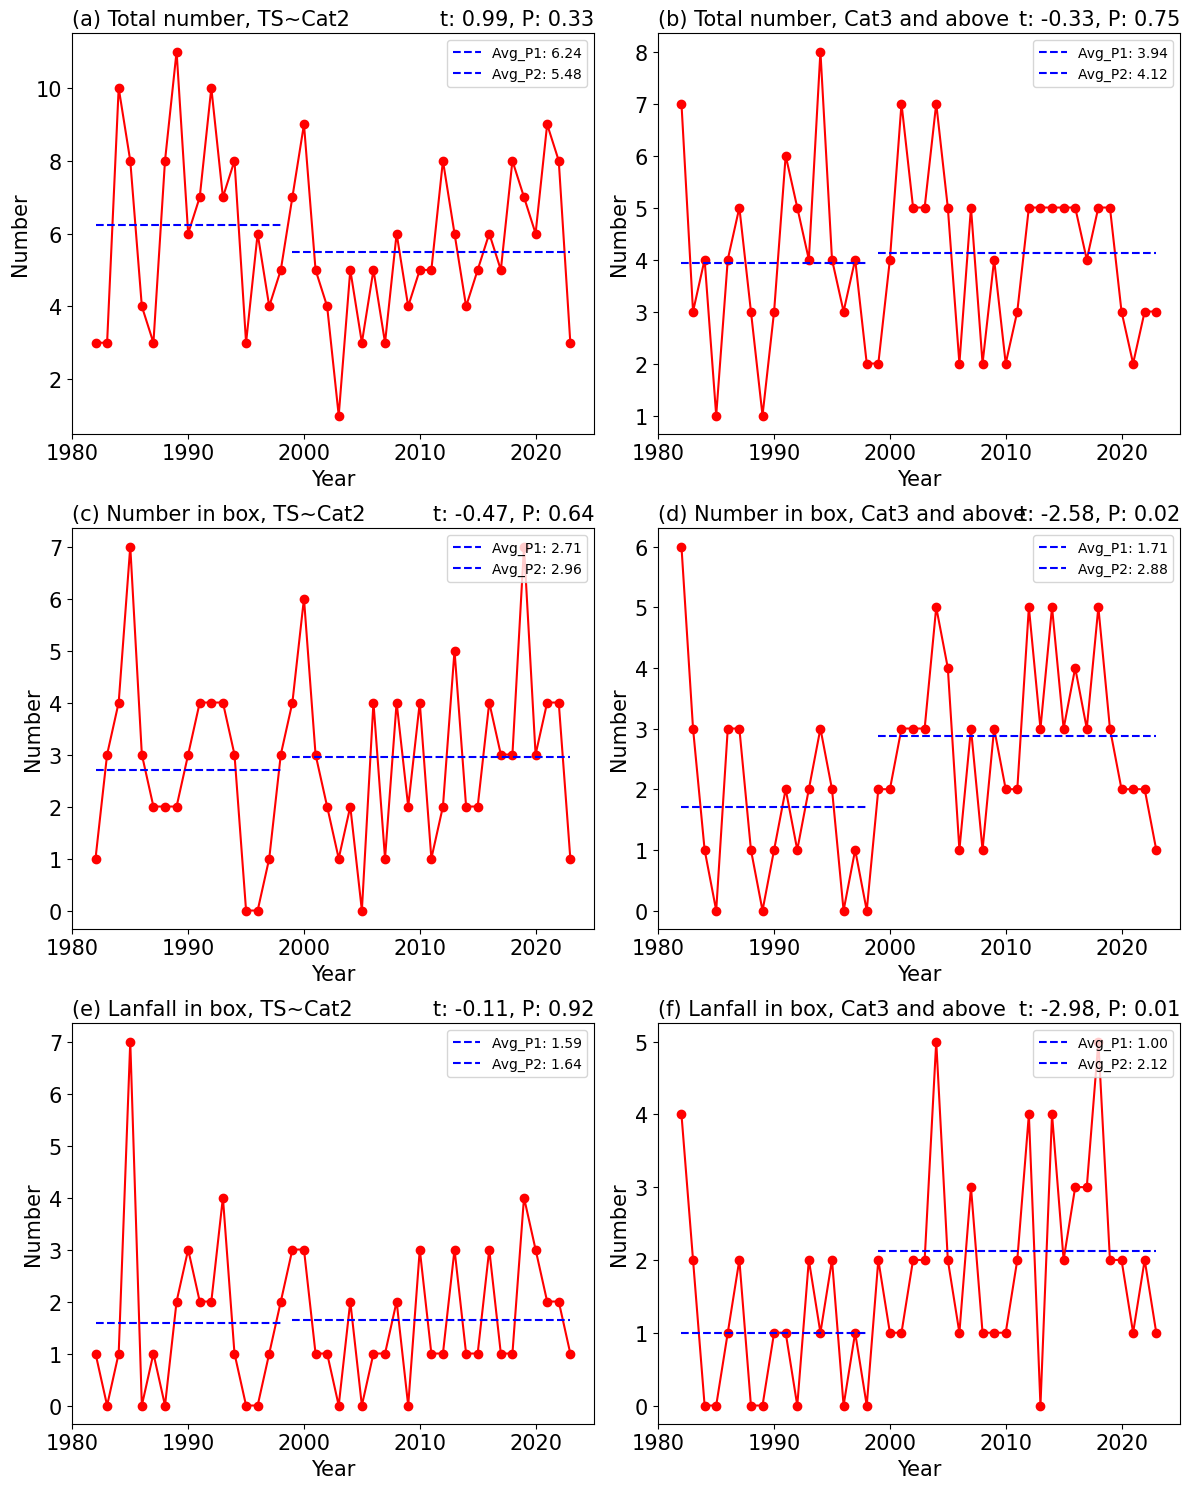

In [20]:
split_index=17
fig=plt.figure(figsize=(12,15))

ax5 = fig.add_subplot(3, 2, 1)
ax=ax5
data=np.array(y5)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(a) Total number, TS~Cat2',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax6 = fig.add_subplot(3, 2, 2)
ax=ax6
data=np.array(y6)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(b) Total number, Cat3 and above',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax1 = fig.add_subplot(3, 2, 3)
ax=ax1
data=np.array(y1)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(c) Number in box, TS~Cat2',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax2 = fig.add_subplot(3, 2, 4)
ax=ax2
data=y2
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(d) Number in box, Cat3 and above',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax3 = fig.add_subplot(3, 2, 5)
ax=ax3
data=y3
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(e) Lanfall in box, TS~Cat2',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax4 = fig.add_subplot(3, 2, 6)
ax=ax4
data=y4
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(f) Lanfall in box, Cat3 and above',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
plt.tight_layout()
plt.show()

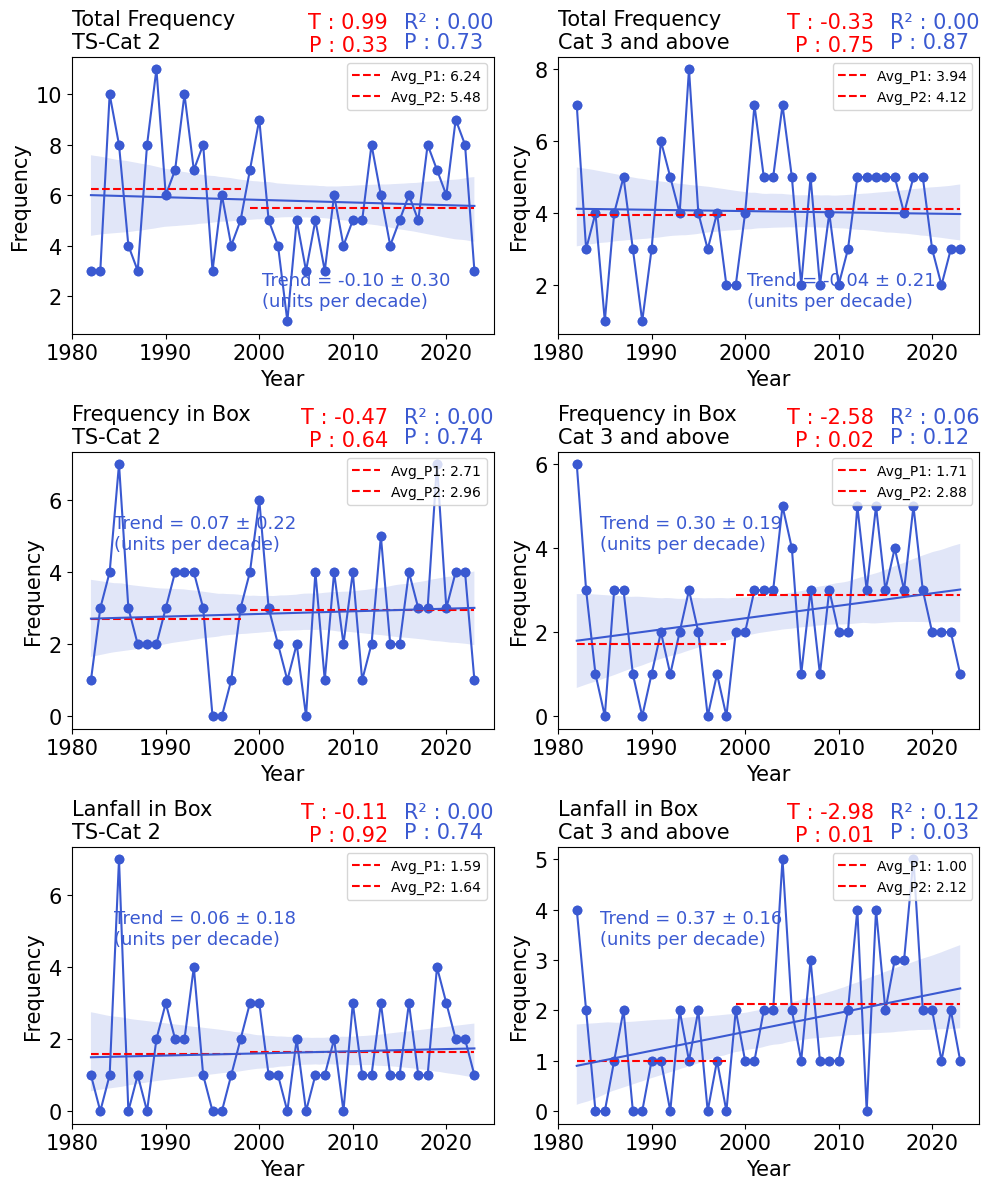

In [21]:
split_index=17
color1='#3A59D1'
color2=color1
color3='r'
fig=plt.figure(figsize=(10,12))

ax5 = fig.add_subplot(3, 2, 1)
ax=ax5
data=np.array(y5)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Total Frequency\nTS-Cat 2',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.45,0.1,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.09, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




ax6 = fig.add_subplot(3, 2, 2)
ax=ax6
data=np.array(y6)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Total Frequency\nCat 3 and above',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.45,0.1,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.09, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)


ax1 = fig.add_subplot(3, 2, 3)
ax=ax1
data=np.array(y1)
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Frequency in Box\nTS-Cat 2',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.1,0.65,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.09, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)


ax2 = fig.add_subplot(3, 2, 4)
ax=ax2
data=y2
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Frequency in Box\nCat 3 and above',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.1,0.65,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.09, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)



ax3 = fig.add_subplot(3, 2, 5)
ax=ax3
data=y3
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Lanfall in Box\nTS-Cat 2',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.1,0.65,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.09, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)


ax4 = fig.add_subplot(3, 2, 6)
ax=ax4
data=y4
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Lanfall in Box\nCat 3 and above',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.1,0.65,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.09, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)

plt.tight_layout()
plt.savefig("Figure S10.pdf",transparent = True)
plt.show()

In [22]:
px95=np.sum(y5[:17])
px96=np.sum(y6[:17])
px=px95+px96
print(px95,px96,px)

106 67 173


In [23]:
py95=np.sum(y5[17:])
py96=np.sum(y6[17:])
py=py95+py96
print(py95,py96,py)

137 103 240


In [24]:
bar1=(px95/px)*100
bar2=(px96/px)*100
bar3=(py95/py)*100
bar4=(py96/py)*100
print(bar1,bar2,bar3,bar4)

61.27167630057804 38.72832369942196 57.08333333333333 42.916666666666664


## 柱状图

In [25]:
p195=np.sum(y1[:17])
p196=np.sum(y2[:17])
p1=p195+p196
print(p195,p196,p1)

46 29 75


In [26]:
p295=np.sum(y1[17:])
p296=np.sum(y2[17:])
p2=p295+p296
print(p295,p296,p2)

74 72 146


In [27]:
bar1=(p195/p1)*100
bar2=(p196/p1)*100
bar3=(p295/p2)*100
bar4=(p296/p2)*100
print(bar1,bar2,bar3,bar4)

61.33333333333333 38.666666666666664 50.68493150684932 49.31506849315068


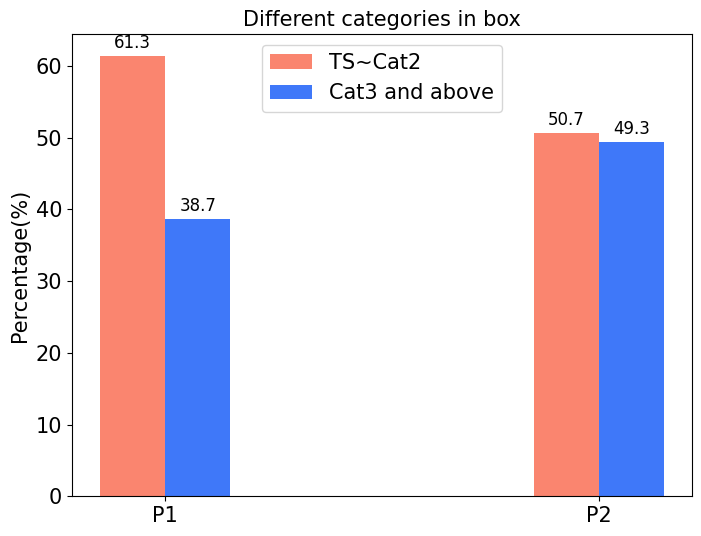

In [28]:
labels = ('P1','P2')
buy_number_male = [bar1,bar3]  # P1
buy_number_female = [bar2,bar4]  # P2

bar_width = 0.15  # 条形宽度
index_male = np.arange(len(labels))  # 男生条形图的横坐标
index_female = index_male + bar_width  # 女生条形图的横坐标

# 创建图表和坐标轴对象
fig, ax = plt.subplots(figsize=(8, 6))
bars_male = ax.bar(index_male, height=buy_number_male, width=bar_width, color='#fa856f', label='TS~Cat2')
bars_female = ax.bar(index_female, height=buy_number_female, width=bar_width, color='#3f78f9', label='Cat3 and above')
ax.bar_label(bars_male, fmt='%.1f', padding=3,fontsize=12)
ax.bar_label(bars_female, fmt='%.1f', padding=3,fontsize=12)


plt.legend(loc='upper center',fontsize=15)  
plt.xticks(index_male + bar_width/2, labels,fontsize=15)  
plt.ylabel('Percentage(%)',fontsize=15)  
plt.tick_params(axis='y', labelsize=15)
plt.title('Different categories in box',fontsize=15)  
plt.show()

In [29]:
landp195=np.sum(y3[:17])
landp196=np.sum(y4[:17])
landp1=landp195+landp196
print(landp195,landp196,landp1)
landp295=np.sum(y3[17:])
landp296=np.sum(y4[17:])
landp2=landp295+landp296
print(landp295,landp296,landp2)
landbar1=(landp195/landp1)*100
landbar2=(landp196/landp1)*100
landbar3=(landp295/landp2)*100
landbar4=(landp296/landp2)*100
print(landbar1,landbar2,landbar3,landbar4)

27 17 44
41 53 94
61.36363636363637 38.63636363636363 43.61702127659575 56.38297872340425


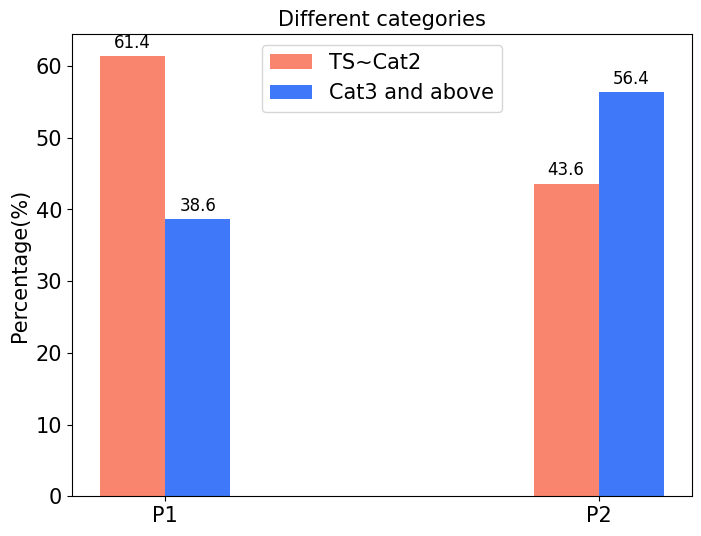

In [30]:
labels = ('P1','P2')
buy_number_male = [landbar1,landbar3]  # P1
buy_number_female = [landbar2,landbar4]  # P2

bar_width = 0.15  # 条形宽度
index_male = np.arange(len(labels))  # 男生条形图的横坐标
index_female = index_male + bar_width  # 女生条形图的横坐标

# 创建图表和坐标轴对象
fig, ax = plt.subplots(figsize=(8, 6))
bars_male = ax.bar(index_male, height=buy_number_male, width=bar_width, color='#fa856f', label='TS~Cat2')
bars_female = ax.bar(index_female, height=buy_number_female, width=bar_width, color='#3f78f9', label='Cat3 and above')
ax.bar_label(bars_male, fmt='%.1f', padding=3,fontsize=12)
ax.bar_label(bars_female, fmt='%.1f', padding=3,fontsize=12)


plt.legend(loc='upper center',fontsize=15)  
plt.xticks(index_male + bar_width/2, labels,fontsize=15)  
plt.ylabel('Percentage(%)',fontsize=15)  
plt.tick_params(axis='y', labelsize=15)
plt.title('Different categories',fontsize=15)  
plt.show()

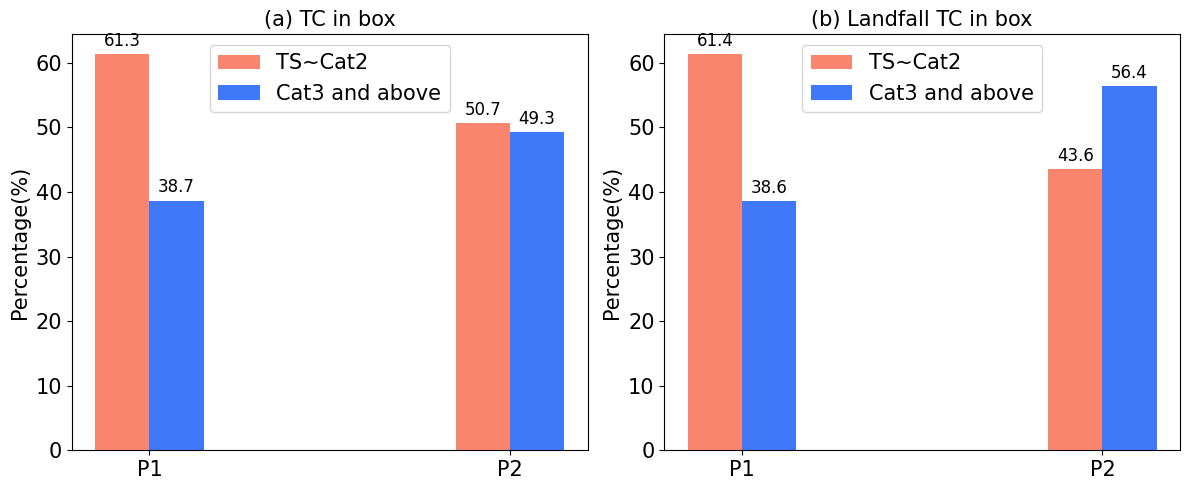

In [31]:
fig=plt.figure(figsize=(12,5))

labels = ('P1','P2')
ax5 = fig.add_subplot(1, 2, 1)
ax=ax5
buy_number_male = [bar1,bar3]  # P1
buy_number_female = [bar2,bar4]  # P2
bar_width = 0.15  # 条形宽度
index_male = np.arange(len(labels))  # 男生条形图的横坐标
index_female = index_male + bar_width  # 女生条形图的横坐标
bars_male = ax.bar(index_male, height=buy_number_male, width=bar_width, color='#fa856f', label='TS~Cat2')
bars_female = ax.bar(index_female, height=buy_number_female, width=bar_width, color='#3f78f9', label='Cat3 and above')
ax.bar_label(bars_male, fmt='%.1f', padding=3,fontsize=12)
ax.bar_label(bars_female, fmt='%.1f', padding=3,fontsize=12)
plt.legend(loc='upper center',fontsize=15)  
plt.xticks(index_male + bar_width/2, labels,fontsize=15)  
plt.ylabel('Percentage(%)',fontsize=15)  
plt.tick_params(axis='y', labelsize=15)
plt.title('(a) TC in box',fontsize=15)

ax6 = fig.add_subplot(1, 2, 2)
ax=ax6
labels = ('P1','P2')
buy_number_male = [landbar1,landbar3]  # P1
buy_number_female = [landbar2,landbar4]  # P2
index_male = np.arange(len(labels))  # 男生条形图的横坐标
index_female = index_male + bar_width  # 女生条形图的横坐标
bars_male = ax.bar(index_male, height=buy_number_male, width=bar_width, color='#fa856f', label='TS~Cat2')
bars_female = ax.bar(index_female, height=buy_number_female, width=bar_width, color='#3f78f9', label='Cat3 and above')
ax.bar_label(bars_male, fmt='%.1f', padding=3,fontsize=12)
ax.bar_label(bars_female, fmt='%.1f', padding=3,fontsize=12)
plt.legend(loc='upper center',fontsize=15)  
plt.xticks(index_male + bar_width/2, labels,fontsize=15)  
plt.ylabel('Percentage(%)',fontsize=15)  
plt.tick_params(axis='y', labelsize=15)
plt.title('(b) Landfall TC in box',fontsize=15)


plt.tight_layout()
plt.show()